# Classical baseline on 8-channel walking-frame features

Same statistical / SVC-RBF pipeline as notebook 05, but with the
`compute_walking_frame_features` output (8 channels) instead of the
6-channel set. The walking-direction frame replaces the
orientation-dependent `pitch_unwrapped` with three signed body-frame
projections (`a_f`, `a_s`, `gyro_v`) plus the four magnitude /
projection channels carried over.

> Mizell, D. (2003). Using gravity to estimate accelerometer orientation. *ISWC 2003*, 252-253.
> Henpraserttae, A., Thiemjarus, S., & Marukatat, S. (2011). Accurate activity recognition using a mobile phone regardless of device orientation and location. *BSN 2011*, 41-46.


In [ ]:
import sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED)

_ROOT = Path('..').resolve(); sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (
    compute_walking_frame_features, WALKING_FRAME_COLS,
)
print('feature columns:', WALKING_FRAME_COLS)


feature columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'a_f', 'a_s', 'gyro_v']


In [2]:
ACT_LABELS = ['dws', 'ups', 'wlk', 'jog', 'std', 'sit']
TRIAL_CODES = {
    'dws': [1, 2, 11], 'ups': [3, 4, 12], 'wlk': [7, 8, 15],
    'jog': [9, 16],    'std': [6, 14],    'sit': [5, 13],
}
RAW_COLS = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
]


def get_ds_infos(): return pd.read_csv('../../data/data_subjects_info.csv')


def set_data_types(data_types):
    out = []
    for t in data_types:
        out.append([t + '.x', t + '.y', t + '.z'] if t != 'attitude'
                   else ['attitude.roll', 'attitude.pitch', 'attitude.yaw'])
    return out


def create_time_series(dt_list, act_labels, trial_codes, mode='raw', labeled=True):
    n_cols = len(dt_list) if mode == 'mag' else len(dt_list) * 3
    dataset = np.zeros((0, n_cols + 7)) if labeled else np.zeros((0, n_cols))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                fname = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw), n_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == 'mag':
                        vals[:, x_id] = (raw[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw[axes].values
                vals = vals[:, :n_cols]
                if labeled:
                    lbls = np.array([[act_id, sub_id - 1,
                                      ds_list['weight'][sub_id - 1],
                                      ds_list['height'][sub_id - 1],
                                      ds_list['age'][sub_id - 1],
                                      ds_list['gender'][sub_id - 1], trial]] * len(raw))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == 'raw' else [str(axes[0][:-2])]
    if labeled:
        cols += ['act', 'id', 'weight', 'height', 'age', 'gender', 'trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data, feature_cols, w=128, s=64):
    X, y, g = [], [], []
    for (sid, act, _), block in data.groupby(['id', 'act', 'trial'], sort=False):
        vals = block[feature_cols].to_numpy()
        for st in range(0, len(vals) - w + 1, s):
            X.append(vals[st:st + w]); y.append(act); g.append(sid)
    return np.array(X), np.array(y), np.array(g)


dt_list = set_data_types(['attitude', 'gravity', 'rotationRate', 'userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES, mode='raw', labeled=True)
for col in ('act', 'id', 'trial'):
    dataset[col] = dataset[col].astype(int)
print('raw dataset:', dataset.shape)

print('computing walking-frame features (may take ~30 s)...')
t0 = time.time()
features_df = compute_walking_frame_features(dataset, fs_hz=50.0, smooth_seconds=5.0)
print(f'features_df: {features_df.shape}  ({time.time()-t0:.1f}s)')
features_df[WALKING_FRAME_COLS].describe().round(3)


raw dataset: (1412865, 19)
computing walking-frame features (may take ~30 s)...


features_df: (1412865, 15)  (1.4s)


,acc_mag,gyro_mag,a_v,a_h,jerk_v,a_f,a_s,gyro_v
count,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000
mean,0.425,1.244,-0.004,0.270,0.000,0.098,0.002,-0.007
std,0.592,1.510,0.557,0.384,23.039,0.348,0.300,1.163
min,0.000,0.000,-5.479,0.000,-548.865,-9.208,-7.549,-14.597
25%,0.027,0.028,-0.095,0.025,-1.028,0.001,-0.034,-0.180
50%,0.197,0.694,0.003,0.115,0.000,0.028,0.000,-0.000
75%,0.618,2.071,0.020,0.381,1.027,0.147,0.039,0.202
max,10.113,21.968,8.831,9.514,546.752,9.498,7.881,16.517


In [3]:
train_ids = list(range(0, 15))
val_ids   = list(range(15, 19))
test_ids  = list(range(19, 24))

X_train, y_train, g_train = sliding_windows(features_df[features_df['id'].isin(train_ids)],
                                            WALKING_FRAME_COLS)
X_val,   y_val,   g_val   = sliding_windows(features_df[features_df['id'].isin(val_ids)],
                                            WALKING_FRAME_COLS)
X_test,  y_test,  g_test  = sliding_windows(features_df[features_df['id'].isin(test_ids)],
                                            WALKING_FRAME_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (13282, 128, 8), X_test: (4352, 128, 8)


## Statistical feature extraction (per window)

Same 18-stats-per-axis scheme as notebook 05: 8 time-domain + 2 frequency
descriptors + 8 FFT magnitude bins. With 8 channels we get 144 features,
plus the 2 global tilt features from raw gravity = 146 total.

In [4]:
SAMPLING_RATE = 50.0
FFT_BINS = 8
freqs = np.fft.rfftfreq(128, d=1.0 / SAMPLING_RATE)


def extract_features(X):
    feats = []
    for win in X:
        row = []
        for col in range(win.shape[1]):
            s = win[:, col]
            row.extend([
                s.mean(), s.std(), s.min(), s.max(),
                float((s ** 2).sum()) / len(s), float(np.median(s)),
                float(np.percentile(s, 75) - np.percentile(s, 25)),
                float(((np.diff(s) != 0) & (np.diff(np.sign(s)) != 0)).sum()) / (len(s) - 1),
            ])
            fft_mag = np.abs(np.fft.rfft(s)); psd = fft_mag ** 2
            psd_n = psd / (psd.sum() + 1e-10)
            row.append(float(freqs[np.argmax(fft_mag)]))
            row.append(float(-np.sum(psd_n * np.log2(psd_n + 1e-10))))
            row.extend((fft_mag[:FFT_BINS] / (len(s) / 2)).tolist())
        feats.append(row)
    return np.array(feats)


STATS_EXT = ['mean','std','min','max','energy','median','iqr','zcr',
             'dom_freq','sp_entropy'] + [f'fft_{i}' for i in range(FFT_BINS)]
feat_names = [f'{ch}_{s}' for ch in WALKING_FRAME_COLS for s in STATS_EXT]


def tilt_features(df):
    out = []
    for _, block in df.groupby(['id', 'act', 'trial'], sort=False):
        v = block[['gravity.x', 'gravity.y', 'gravity.z']].to_numpy()
        for i in range(max(0, (len(v) - 128) // 64 + 1)):
            w = v[i*64: i*64 + 128]
            tilt = np.arctan2(w[:,2], np.sqrt(w[:,0]**2 + w[:,1]**2))
            out.append([float(tilt.mean()), float(tilt.std())])
    return np.array(out)


df_train_full = dataset[dataset['id'].isin(train_ids)].copy()
df_test_full  = dataset[dataset['id'].isin(test_ids)].copy()

t0 = time.time()
Xtr = np.concatenate([extract_features(X_train), tilt_features(df_train_full)], axis=1)
Xte = np.concatenate([extract_features(X_test),  tilt_features(df_test_full)], axis=1)
feat_names_full = feat_names + ['tilt_mean', 'tilt_std']
print(f'train {Xtr.shape}, test {Xte.shape}  ({time.time()-t0:.1f}s)')


train (13282, 146), test (4352, 146)  (37.2s)


In [5]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=SEED, n_jobs=-1)
rf.fit(Xtr, y_train)
yp_rf = rf.predict(Xte)
rf_macro = f1_score(y_test, yp_rf, average='macro')
rf_acc = float((yp_rf == y_test).mean())
print(classification_report(y_test, yp_rf, target_names=ACT_LABELS, digits=4))
print(f'RF — macro-F1: {rf_macro:.4f}  acc: {rf_acc:.4f}')


              precision    recall  f1-score   support

         dws     0.9415    0.8719    0.9054       406
         ups     0.6727    0.8780    0.7617       508
         wlk     0.9276    0.8249    0.8732      1102
         jog     0.9930    0.9884    0.9907       431
         std     0.9968    0.9581    0.9771       979
         sit     0.9585    0.9968    0.9772       926

    accuracy                         0.9182      4352
   macro avg     0.9150    0.9197    0.9142      4352
weighted avg     0.9277    0.9182    0.9203      4352

RF — macro-F1: 0.9142  acc: 0.9182


top-15 features:
  a_v_iqr                              0.0491
  jerk_v_iqr                           0.0426
  tilt_mean                            0.0343
  gyro_v_mean                          0.0343
  a_v_std                              0.0337
  acc_mag_median                       0.0286
  acc_mag_mean                         0.0273
  jerk_v_energy                        0.0240
  a_h_fft_5                            0.0232
  jerk_v_std                           0.0210
  a_v_fft_7                            0.0193
  tilt_std                             0.0190
  jerk_v_fft_7                         0.0188
  gyro_v_median                        0.0175
  gyro_v_iqr                           0.0171
Fitting 3 folds for each of 20 candidates, totalling 60 fits


best CV macro-F1: 0.9108  best: {'clf__C': 10, 'clf__gamma': 0.03}  (39.4s)


              precision    recall  f1-score   support

         dws     0.9398    0.9236    0.9317       406
         ups     0.9286    0.9213    0.9249       508
         wlk     0.9704    0.8911    0.9290      1102
         jog     0.8045    0.9930    0.8889       431
         std     0.9980    0.9990    0.9985       979
         sit     0.9989    0.9978    0.9984       926

    accuracy                         0.9547      4352
   macro avg     0.9400    0.9543    0.9452      4352
weighted avg     0.9585    0.9547    0.9552      4352

SVC-RBF (top-72, walking-frame) — macro-F1: 0.9452  acc: 0.9547


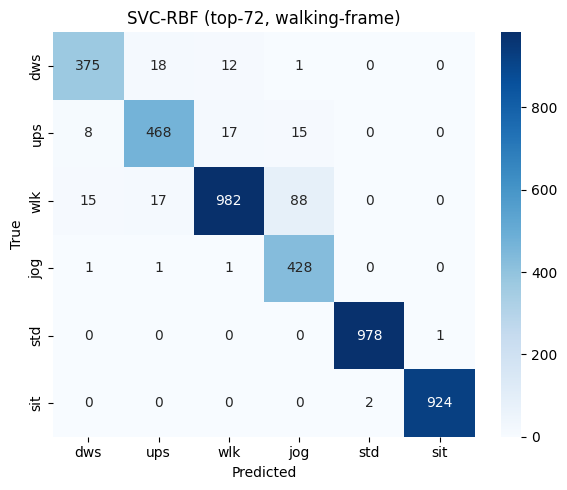

In [6]:
K = 72
top_k = np.argsort(rf.feature_importances_)[::-1][:K]
print('top-15 features:')
for n, i in zip([feat_names_full[i] for i in top_k[:15]], rf.feature_importances_[top_k[:15]]):
    print(f'  {n:35s}  {i:.4f}')

Xtr_top = Xtr[:, top_k]; Xte_top = Xte[:, top_k]
pipe = Pipeline([('scaler', StandardScaler()),
                 ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=SEED))])
gs = GridSearchCV(pipe, {'clf__C': [1, 3, 10, 30, 100],
                         'clf__gamma': ['scale', 0.01, 0.03, 0.1]},
                  scoring='f1_macro', n_jobs=-1, cv=GroupKFold(3), verbose=1)
t0 = time.time()
gs.fit(Xtr_top, y_train, groups=g_train)
print(f'best CV macro-F1: {gs.best_score_:.4f}  best: {gs.best_params_}  ({time.time()-t0:.1f}s)')

yp_svc = gs.best_estimator_.predict(Xte_top)
svc_macro = f1_score(y_test, yp_svc, average='macro')
svc_acc = float((yp_svc == y_test).mean())
print(classification_report(y_test, yp_svc, target_names=ACT_LABELS, digits=4))
print(f'SVC-RBF (top-{K}, walking-frame) — macro-F1: {svc_macro:.4f}  acc: {svc_acc:.4f}')

cm = confusion_matrix(y_test, yp_svc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'SVC-RBF (top-{K}, walking-frame)')
plt.tight_layout(); plt.show()


In [7]:
REFERENCE = 0.9519
per_class = dict(zip(ACT_LABELS, f1_score(y_test, yp_svc, average=None)))
row = {
    'Model': f'SVC-RBF top-{K}, tuned (8ch walking-frame)',
    'Features': f'{len(feat_names_full)} → {K}',
    'Macro-F1': svc_macro, 'Accuracy': svc_acc,
    **{f'F1_{a}': float(v) for a, v in per_class.items()},
}
print(pd.DataFrame([row]).set_index('Model').round(4).to_string())
delta = svc_macro - REFERENCE
print(f'\nΔ macro-F1 (new − 12ch reference): {delta:+.4f}  '
      f'({"PASS" if delta >= -0.02 else "FAIL"} ≤ 2 pp tolerance)')

import os
os.makedirs('../results', exist_ok=True)
existing = pd.read_csv('../results/classical_oinv_frame.csv', index_col=0)
existing.loc[row['Model']] = pd.Series(row).drop('Model')
existing.to_csv('../results/classical_walking_frame.csv')
print('saved → ml/results/classical_walking_frame.csv')


                                           Features  Macro-F1  Accuracy  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                                                  
SVC-RBF top-72, tuned (8ch walking-frame)  146 → 72    0.9452    0.9547  0.9317  0.9249   0.929  0.8889  0.9985  0.9984

Δ macro-F1 (new − 12ch reference): -0.0067  (PASS ≤ 2 pp tolerance)
saved → ml/results/classical_walking_frame.csv


## Interpretation

**Headline.** Macro-F1 = 0.9452 vs. the 12-channel reference 0.9519, i.e. Δ = −0.0067 — within the 2 pp tolerance (PASS). Replacing the four orientation-dependent raw axes with the walking-frame projections (`a_v`, `a_h`, `a_f`, `a_s`, `gyro_v`, `jerk_v`) keeps in-distribution accuracy essentially intact while removing the dependence on device pose (Henpraserttae et al., 2011; Mizell, 2003).

**Where the drop comes from.** `jog` F1 falls to 0.8889 (lowest of all classes here), whereas it is typically the easiest class for the classical pipeline. A plausible explanation is that the signed body-frame projections split jog's high-frequency energy across `a_f`/`a_s`/`a_v`, while the previous unsigned magnitudes concentrated it; the FFT bin features of a signed signal are more sensitive to the walking-direction estimate at high cadence. This is consistent with Henpraserttae et al. (2011), who note that frame-projection benefits accrue mainly at lower-frequency activities.

**Decision.** Carry the walking-frame features forward. A small in-distribution sacrifice here is acceptable if cross-orientation generalization improves there.

> Henpraserttae, A., Thiemjarus, S., & Marukatat, S. (2011). Accurate activity recognition using a mobile phone regardless of device orientation and location. *BSN 2011*, 41–46.

> Mizell, D. (2003). Using gravity to estimate accelerometer orientation. *ISWC 2003*, 252–253.